In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

plt.style.use('ggplot')

print(" Libraries Imported Successfully")

 Libraries Imported Successfully


In [11]:
df = pd.read_csv("IBM_HR_Attrition.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [14]:
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [16]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1470
Columns : 35


In [17]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [18]:
print(df.duplicated().sum())

0


In [19]:
display(df.describe())

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [20]:
attrition_rate = (
    df['Attrition']
    .value_counts(normalize=True)['Yes']
) * 100

print("\n================ ATTRITION RATE ================\n")

print("Overall Employee Attrition Rate :",
      round(attrition_rate, 2), "%")


================ ATTRITION RATE ================

Overall Employee Attrition Rate : 16.12 %


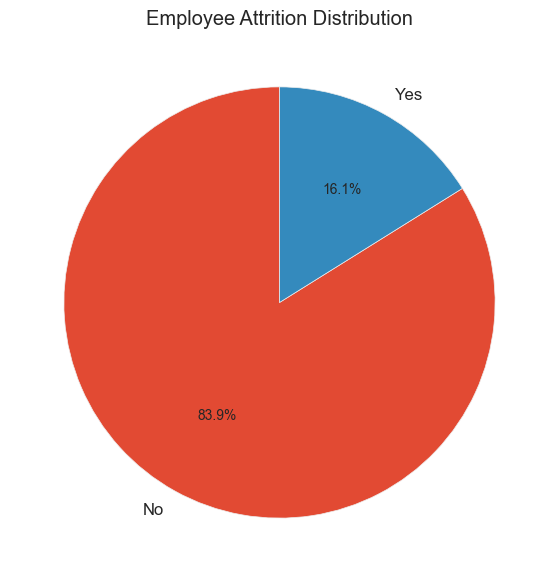

In [21]:
attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Employee Attrition Distribution")

plt.show()

In [22]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition']
)

display(department_attrition)

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


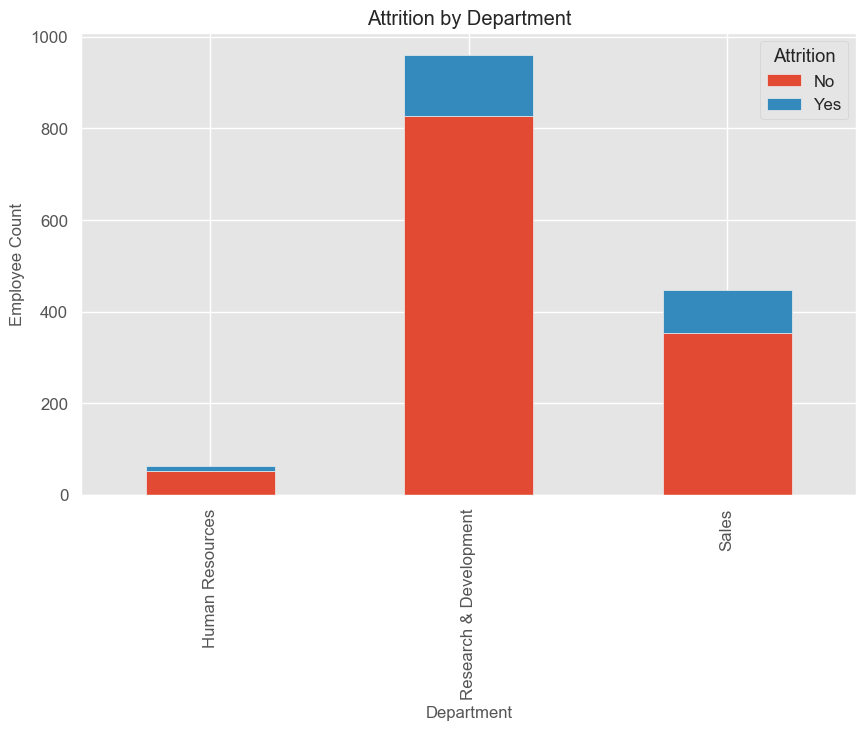

In [23]:
department_attrition.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.show()

In [24]:
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition']
)

display(jobrole_attrition)

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


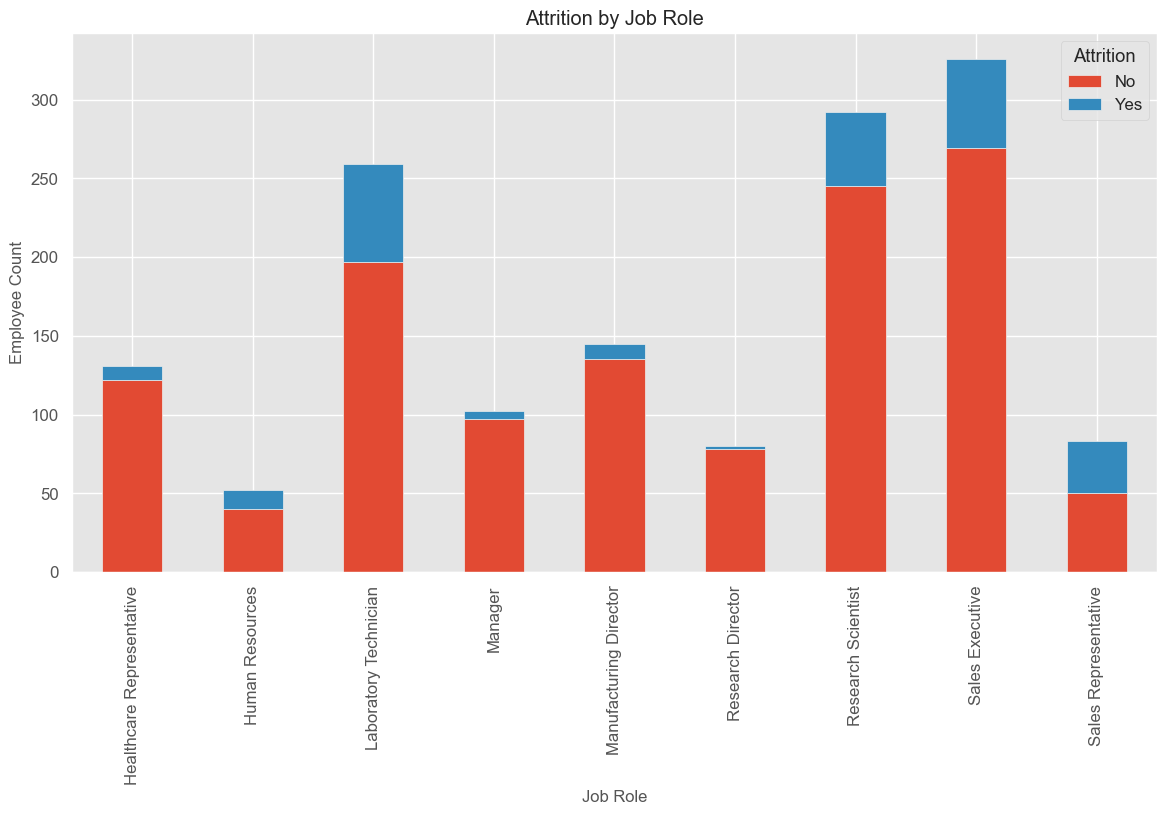

In [25]:
jobrole_attrition.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title("Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Employee Count")

plt.show()

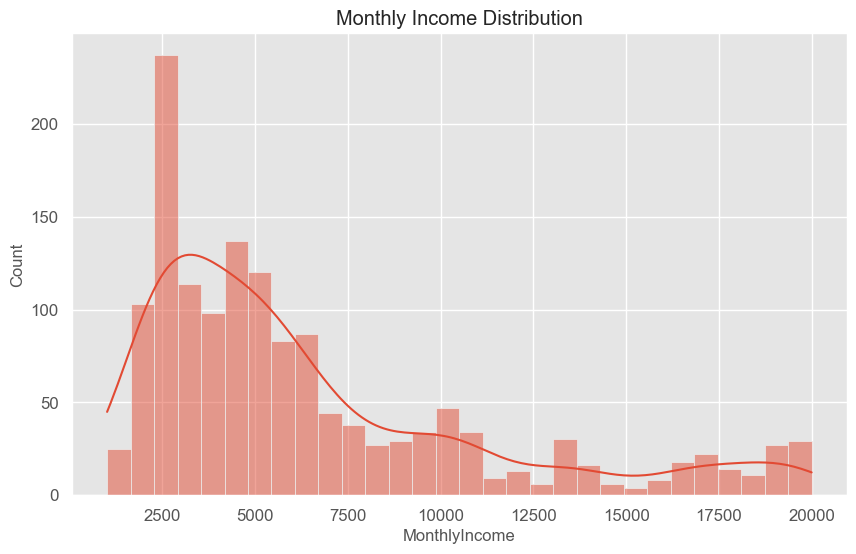

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['MonthlyIncome'],
    bins=30,
    kde=True
)

plt.title("Monthly Income Distribution")

plt.show()

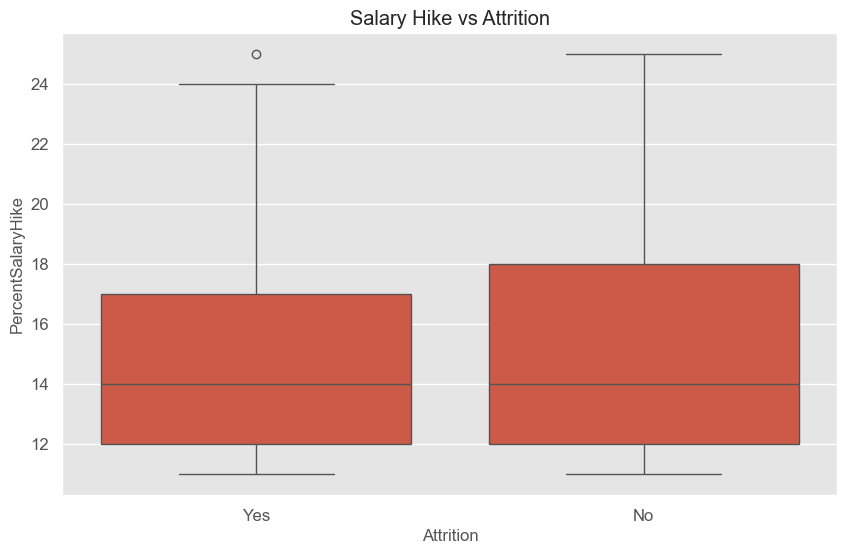

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Attrition',
    y='PercentSalaryHike',
    data=df
)

plt.title("Salary Hike vs Attrition")

plt.show()

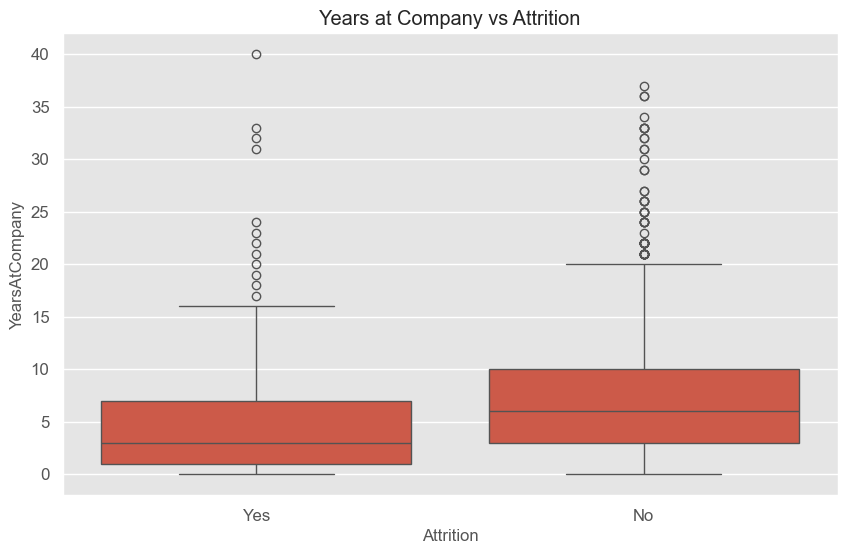

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)

plt.title("Years at Company vs Attrition")

plt.show()

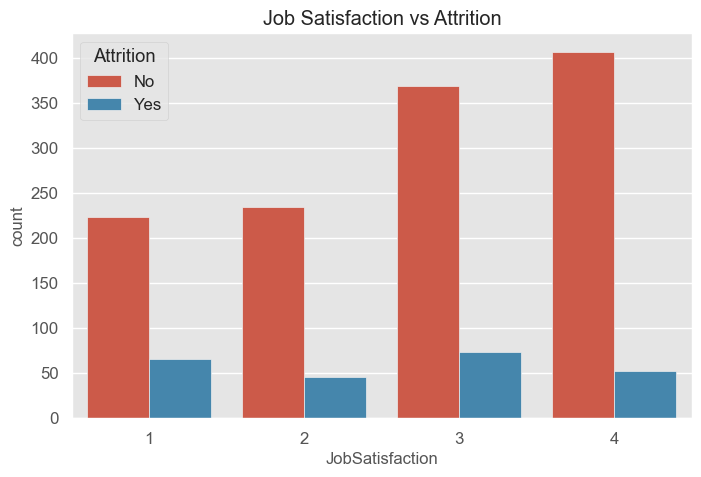

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=df
)

plt.title("Job Satisfaction vs Attrition")

plt.show()

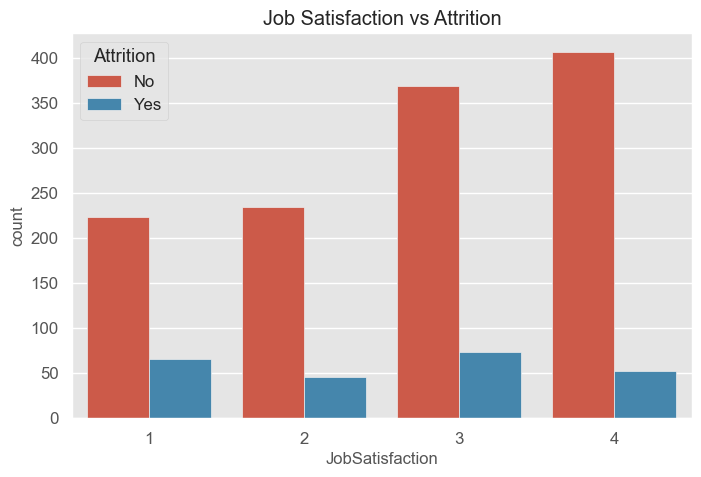

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=df
)

plt.title("Job Satisfaction vs Attrition")

plt.show()

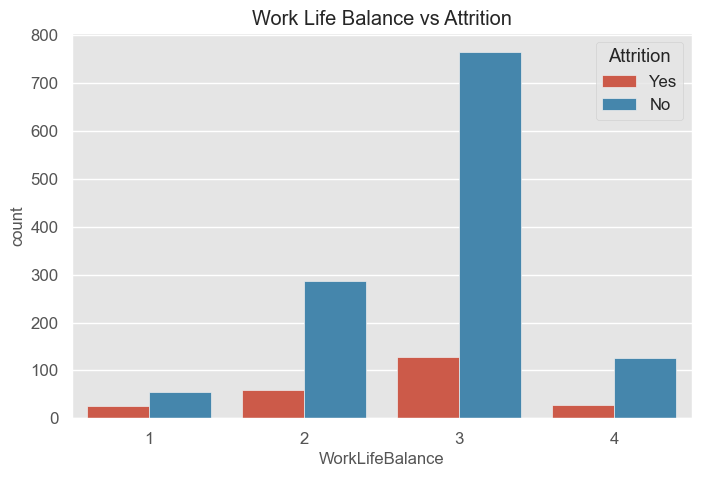

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)

plt.title("Work Life Balance vs Attrition")

plt.show()

In [32]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition']
)

display(overtime_attrition)

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


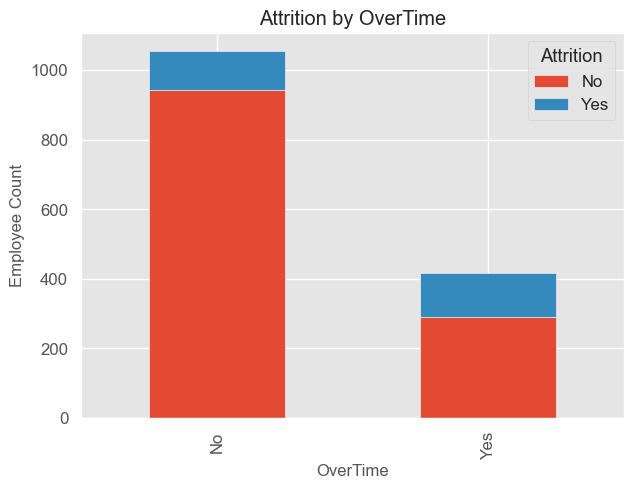

In [33]:
overtime_attrition.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Attrition by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Employee Count")

plt.show()

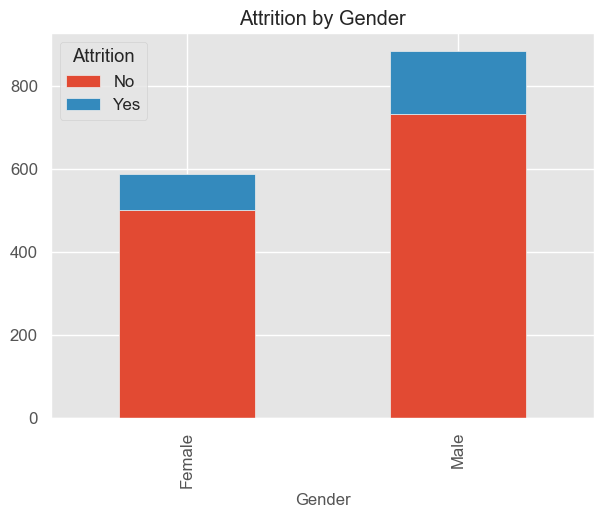

In [34]:
gender_attrition = pd.crosstab(
    df['Gender'],
    df['Attrition']
)

gender_attrition.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Attrition by Gender")

plt.show()

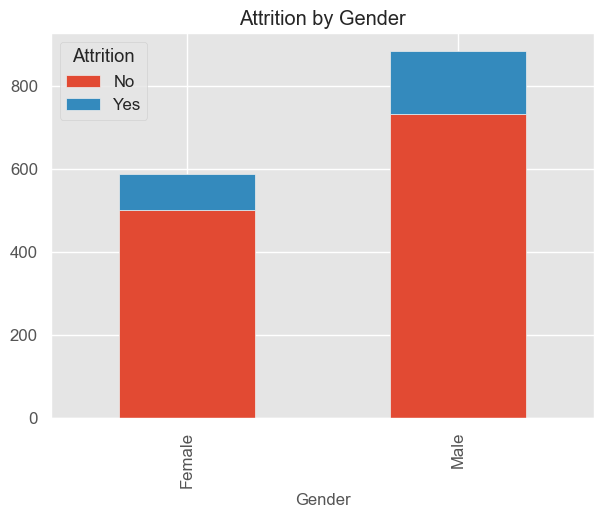

In [35]:
gender_attrition = pd.crosstab(
    df['Gender'],
    df['Attrition']
)

gender_attrition.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Attrition by Gender")

plt.show()

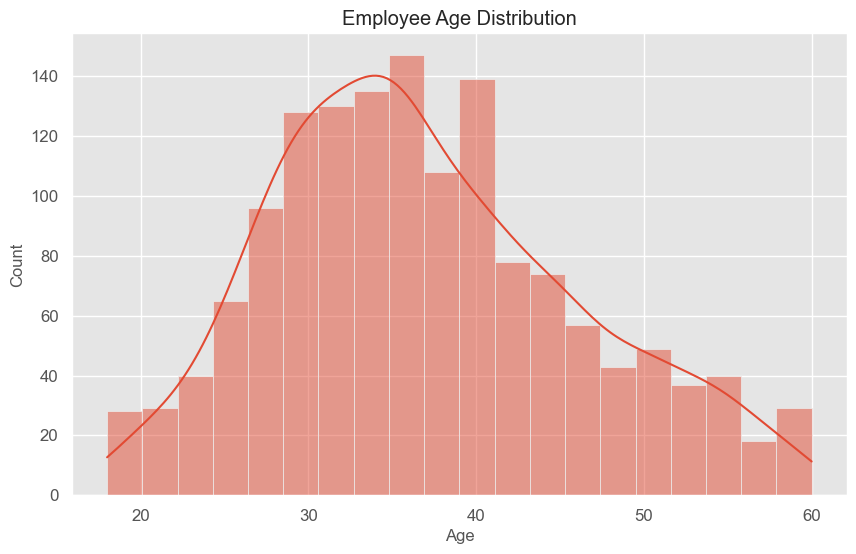

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Employee Age Distribution")

plt.show()

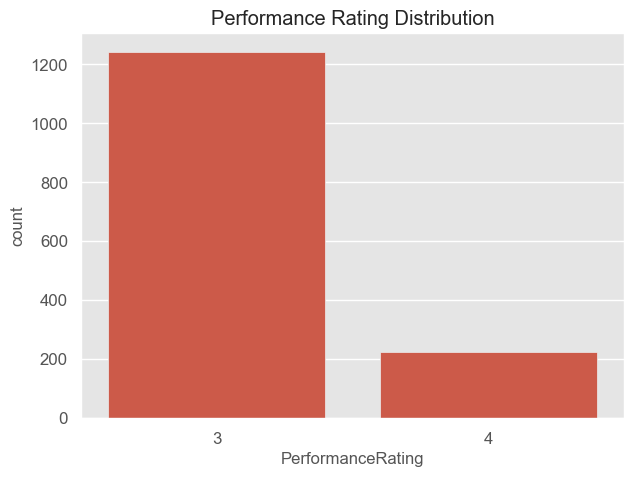

In [37]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='PerformanceRating',
    data=df
)

plt.title("Performance Rating Distribution")

plt.show()

In [39]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_encoded = df.copy()

for col in df_encoded.columns:

    if df_encoded[col].dtype == 'object':

        df_encoded[col] = label_encoder.fit_transform(
            df_encoded[col]
        )

print("Label Encoding Completed")

Label Encoding Completed


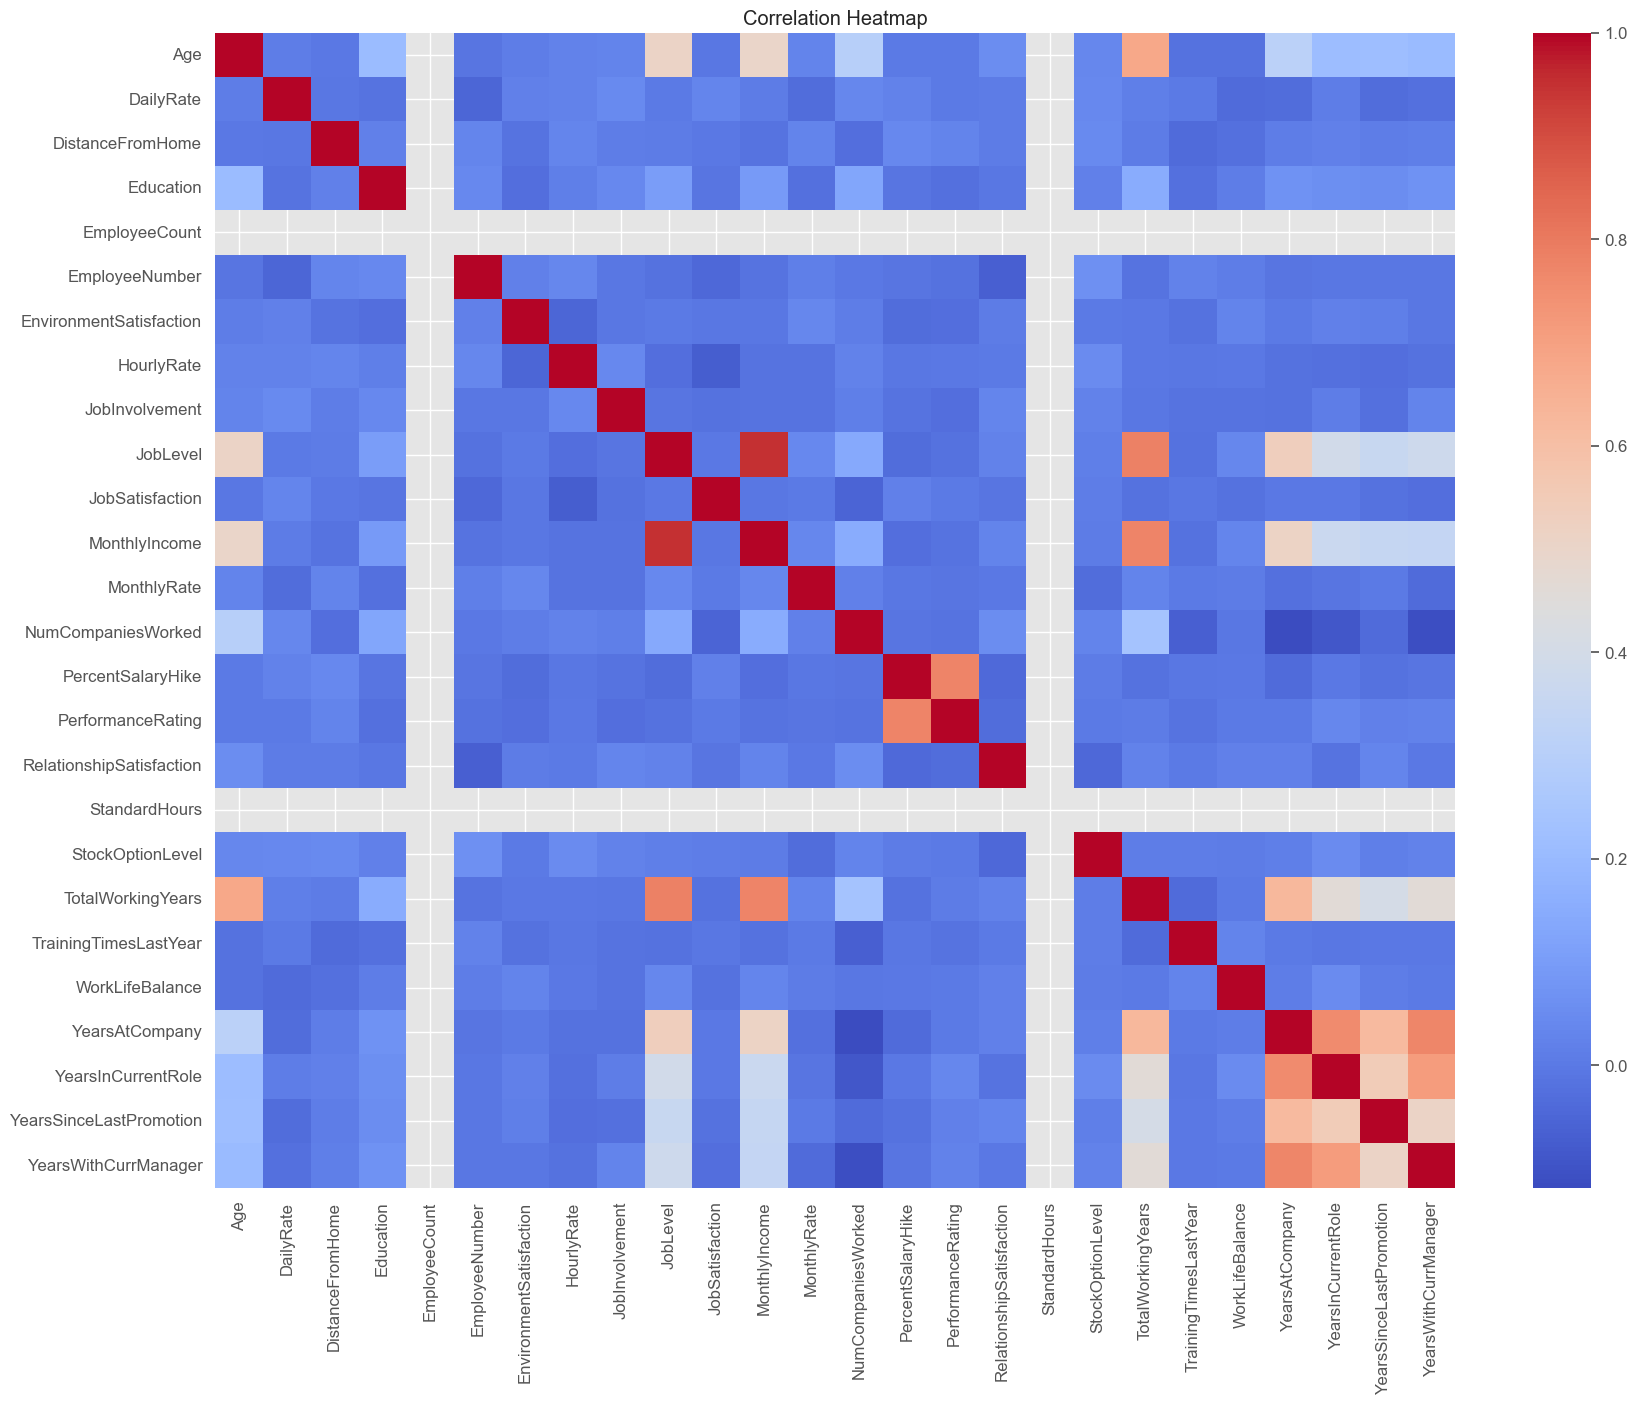

In [41]:
plt.figure(figsize=(20,15))

numeric_df = df_encoded.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

In [42]:
high_risk = df[
    (df['OverTime'] == 'Yes') &
    (df['MonthlyIncome'] < 5000) &
    (df['Attrition'] == 'Yes')
]

print("\n================ HIGH RISK EMPLOYEES ================\n")

display(high_risk.head())


================ HIGH RISK EMPLOYEES ================



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
14,28,Yes,Travel_Rarely,103,Research & Development,24,3,Life Sciences,1,19,...,2,80,0,6,4,3,4,2,0,3
26,32,Yes,Travel_Frequently,1125,Research & Development,16,1,Life Sciences,1,33,...,2,80,0,10,5,3,10,2,6,7
34,24,Yes,Travel_Rarely,813,Research & Development,1,3,Medical,1,45,...,1,80,1,6,2,2,2,0,2,0
36,50,Yes,Travel_Rarely,869,Sales,3,2,Marketing,1,47,...,3,80,0,3,2,3,3,2,0,2


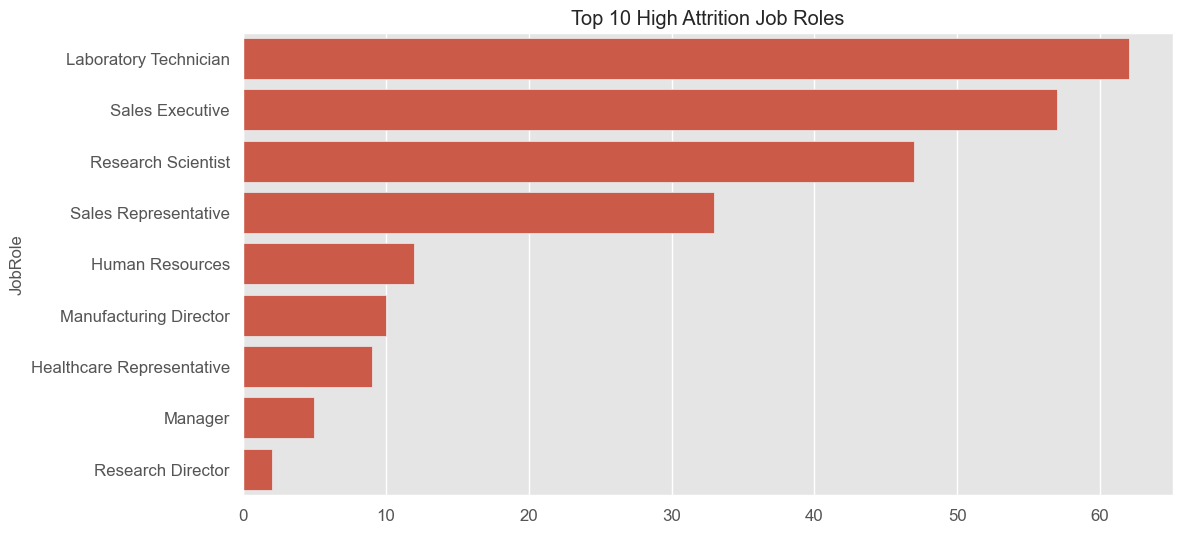

In [43]:
top_roles = (
    df[df['Attrition'] == 'Yes']
    ['JobRole']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_roles.values,
    y=top_roles.index
)

plt.title("Top 10 High Attrition Job Roles")

plt.show()

In [44]:
print("\n================ HR INSIGHTS ================\n")

print("1. Employees working overtime are leaving more frequently.")
print("2. Low salary employees show higher attrition.")
print("3. Sales and Laboratory roles have high turnover.")
print("4. Employees with low job satisfaction leave more.")
print("5. Younger employees are more likely to resign.")


================ HR INSIGHTS ================

1. Employees working overtime are leaving more frequently.
2. Low salary employees show higher attrition.
3. Sales and Laboratory roles have high turnover.
4. Employees with low job satisfaction leave more.
5. Younger employees are more likely to resign.


In [50]:
print("\n============= HR RECOMMENDATIONS ===================                 \n")

print(" Increase salary benefits for low-income employees.")
print(" Reduce excessive overtime workload.")
print(" Improve employee engagement and work-life balance.")


============= HR RECOMMENDATIONS ===================                 

 Increase salary benefits for low-income employees.
 Reduce excessive overtime workload.
 Improve employee engagement and work-life balance.


In [55]:
print("\n🎯 AWIS HR Analytics Study Completed Successfully")


🎯 AWIS HR Analytics Study Completed Successfully
